# NB-08 — LoRA Fine-Tuning

**Goal:** Adapt Qwen2-VL with LoRA adapters (+ trainable projector) on a small multimodal QA dataset.

Concepts: rank decomposition, instruction tuning format, VQA accuracy, checkpoint export.

---

In [1]:
import sys
import json
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

import matplotlib.pyplot as plt
import torch
from dotenv import load_dotenv
from omegaconf import OmegaConf
from PIL import Image
from torch.utils.data import DataLoader

load_dotenv(Path("..") / ".env")

from src.data.dataset import DatasetSplitter, MultimodalQADataset, make_collate_fn
from src.data.preprocessing import build_instruction_prompt, validate_dataset
from src.llm.backbone import MultimodalLLM
from src.llm.lora_finetune import LoRATrainer, apply_lora, count_trainable_params, merge_and_save

DEVICE = "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
DEVICE = "cpu"
MODEL_CFG = Path("..") / "config" / "model_config.yaml"
TRAIN_CFG = Path("..") / "config" / "train_config.yaml"
DATA_DIR = Path("..") / "data" / "sample_vqa"
print(f"Device: {DEVICE}")

Device: cpu


## 1. Dataset prep

Format: JSONL with `{"image": "path", "question": "...", "answer": "..."}`.

Set `DOWNLOAD_SAMPLE=True` to fetch a tiny HF split; otherwise we write a local demo set.

In [2]:
DOWNLOAD_SAMPLE = False  # Set to True to attempt HuggingFace download (may fail due to API limits)
DATA_DIR.mkdir(parents=True, exist_ok=True)
(DATA_DIR / "images").mkdir(exist_ok=True)

if DOWNLOAD_SAMPLE:
    try:
        from datasets import load_dataset
        
        # Alternative VQA datasets on HF Hub:
        # - "Rsimoesartins/VQA_v2_dataset_coco" (may require authentication)
        # - "dandelin/vqa" (smaller, open access)
        ds = load_dataset("dandelin/vqa", split="train", streaming=False)
        ds = ds.select(range(min(100, len(ds))))  # Take first 100 examples
        rows = []
        for i, ex in enumerate(ds):
            img_path = DATA_DIR / "images" / f"{i:04d}.jpg"
            img = ex["image"]
            if isinstance(img, str):
                # If it's a path, skip download attempt
                DOWNLOAD_SAMPLE = False
                raise RuntimeError("Image is path, not PIL Image")
            img.save(img_path)
            rows.append({
                "image": f"images/{img_path.name}",
                "question": ex["question"],
                "answer": ex.get("answer") or ex.get("answers", [{}])[0] or "unknown",
            })
        all_path = DATA_DIR / "all.jsonl"
        all_path.write_text("\n".join(json.dumps(r) for r in rows) + "\n", encoding="utf-8")
        DatasetSplitter().split_file(all_path, DATA_DIR)
    except Exception as e:
        print(f"Warning: could not load VQA dataset: {type(e).__name__} {e}")
        print("Falling back to the tiny local demo dataset.")
        DOWNLOAD_SAMPLE = False

if not DOWNLOAD_SAMPLE:
    # Tiny local demo set (replace with your domain data)
    # This is sufficient for LoRA fine-tuning proof-of-concept
    demo = [
        ("dog", "What animal is shown?", "dog"),
        ("cat", "What animal is shown?", "cat"),
        ("car", "What vehicle is shown?", "car"),
    ]
    rows = []
    for i, (_, q, a) in enumerate(demo * 20):
        img_path = DATA_DIR / "images" / f"{i:03d}.jpg"
        if not img_path.exists():
            color = [(255, 0, 0), (0, 128, 255), (0, 180, 0)][i % 3]
            Image.new("RGB", (128, 128), color).save(img_path)
        rows.append({"image": f"images/{img_path.name}", "question": q, "answer": a})
    all_path = DATA_DIR / "all.jsonl"
    all_path.write_text("\n".join(json.dumps(r) for r in rows) + "\n", encoding="utf-8")
    DatasetSplitter().split_file(all_path, DATA_DIR)

report = validate_dataset(DATA_DIR)
print(report)


{'data_dir': '../data/sample_vqa', 'files': [{'file': 'all.jsonl', 'examples': 60, 'errors': 0}, {'file': 'test.jsonl', 'examples': 6, 'errors': 0}, {'file': 'train.jsonl', 'examples': 48, 'errors': 0}, {'file': 'val.jsonl', 'examples': 6, 'errors': 0}], 'total_examples': 120, 'missing_images': [], 'invalid_lines': [], 'missing_fields': [], 'ok': True}


Q: What animal is shown?
A: dog

Q: What animal is shown?
A: dog

Q: What vehicle is shown?
A: car

Q: What animal is shown?
A: cat

Q: What animal is shown?
A: cat

Q: What animal is shown?
A: cat

Q: What animal is shown?
A: dog

Q: What animal is shown?
A: cat

Q: What animal is shown?
A: cat

Q: What animal is shown?
A: dog



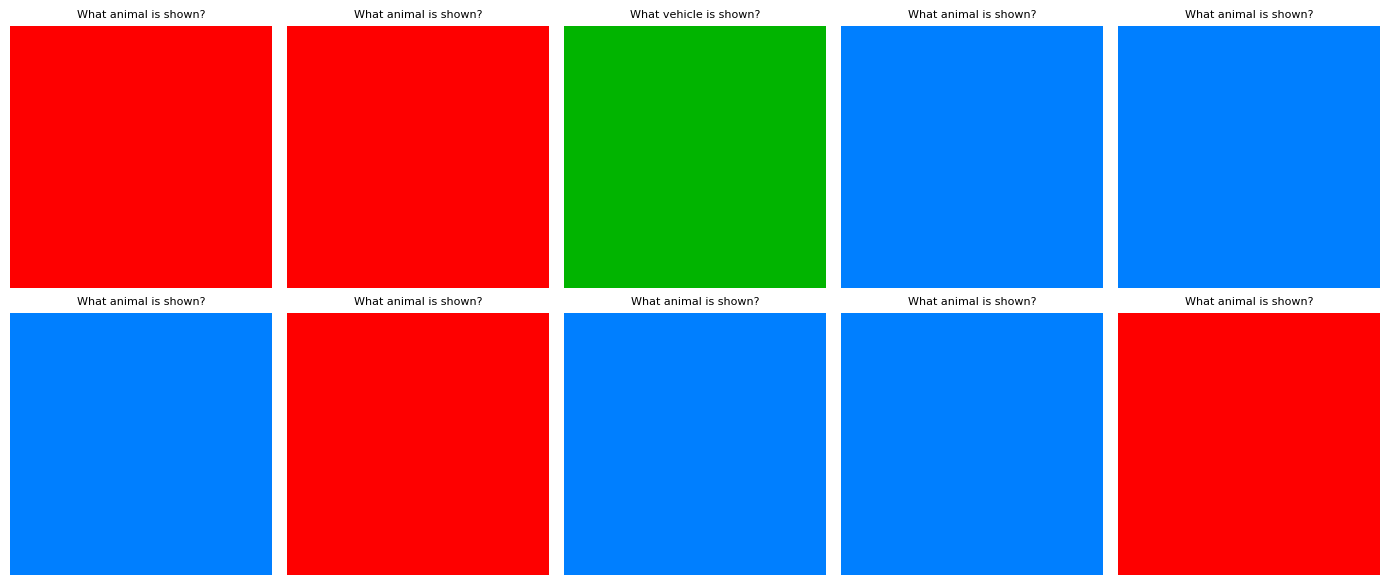

In [3]:
import random

train_lines = (DATA_DIR / "train.jsonl").read_text(encoding="utf-8").strip().splitlines()
sample_rows = [json.loads(ln) for ln in random.sample(train_lines, min(10, len(train_lines)))]

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for ax, row in zip(axes.ravel(), sample_rows):
    img = Image.open(DATA_DIR / row["image"])
    ax.imshow(img)
    ax.set_title(row["question"][:40], fontsize=8)
    ax.axis("off")
    print(f"Q: {row['question']}\nA: {row['answer']}\n")
plt.tight_layout()

In [4]:
train_cfg = OmegaConf.load(TRAIN_CFG)
model = MultimodalLLM.from_config(MODEL_CFG, device=DEVICE, encoder_on_cpu=(DEVICE == "mps"))

example = sample_rows[0]
img = Image.open(DATA_DIR / example["image"]).convert("RGB")
prompt = build_instruction_prompt(example["question"], example["answer"], processor=model.processor, image=img)
print(prompt[:800])

Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

2026-05-26 21:21:40.311 | INFO     | src.llm.backbone:__init__:114 - Loading LLM: Qwen/Qwen2-VL-2B-Instruct


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

2026-05-26 21:21:53.066 | INFO     | src.llm.backbone:__init__:120 - MultimodalLLM ready | device=cpu | llm_hidden=1536 | encoder_on_cpu=False


<|im_start|>system
You are a helpful vision-language assistant. Answer questions about images accurately and concisely.<|im_end|>
<|im_start|>user
<|vision_start|><|image_pad|><|vision_end|>What animal is shown?<|im_end|>
<|im_start|>assistant
dog<|im_end|>



## 2. LoRA configuration

| Param | Role |
|-------|------|
| `r` | Rank of low-rank matrices (capacity vs params) |
| `alpha` | Scaling factor (usually `2*r`) |
| `dropout` | Regularization on adapter paths |
| `target_modules` | Which linear layers get adapters |

In [5]:
lora_cfg = train_cfg.lora
print(OmegaConf.to_yaml(lora_cfg))

# Apply LoRA adapters to full model (preserves generation infrastructure)
model = apply_lora(model, lora_cfg, train_projector=True)

trainable, total = count_trainable_params(model.language_model)
trainable += sum(p.numel() for p in model.projector.parameters() if p.requires_grad)
total += sum(p.numel() for p in model.projector.parameters())
print(f"Trainable: {trainable:,} / {total:,} ({100*trainable/total:.2f}%)")

lora_layers = [n for n, p in model.language_model.named_parameters() if "lora_" in n]
print(f"LoRA parameter groups: {len(lora_layers)}")


r: 8
alpha: 16
dropout: 0.05
target_modules:
- q_proj
- v_proj
- o_proj
- gate_proj



2026-05-26 21:21:54.759 | INFO     | src.llm.lora_finetune:apply_lora:76 - LoRA applied | trainable=9,382,400 / 2,218,368,000 (0.42%)


Trainable: 9,382,400 / 1,553,096,704 (0.60%)
LoRA parameter groups: 224


## 3. Training (proof of concept)

Uses native Qwen2-VL processor path. Reduce `num_epochs` / dataset size for a quick smoke test.

In [6]:
augment = OmegaConf.to_container(train_cfg.augment, resolve=True)
train_ds = MultimodalQADataset(
    DATA_DIR, "train", model.processor,
    max_length=int(train_cfg.training.max_length),
    augment_config=augment,
)
val_ds = MultimodalQADataset(
    DATA_DIR, "val", model.processor,
    max_length=int(train_cfg.training.max_length),
    augment_config={},
)

pad_id = model.tokenizer.pad_token_id or model.tokenizer.eos_token_id
collate = make_collate_fn(pad_id)

trainer = LoRATrainer(model, train_ds, val_ds, train_cfg.training, collate_fn=collate)
history = trainer.train()

Epoch 1/3:   0%|          | 0/12 [00:01<?, ?it/s]


ValueError: Multimodal data was passed (via `image_grid_thw` or `video_grid_thw`) but `mm_token_type_ids` is missing. Please pass `mm_token_type_ids` to the model so that multimodal RoPE (M-RoPE) can be computed correctly. `mm_token_type_ids` is returned by the processor alongside `input_ids`.

In [ ]:
steps = [h["step"] for h in history]
losses = [h["loss"] for h in history]
plt.plot(steps, losses)
plt.xlabel("step")
plt.ylabel("loss")
plt.title("Training loss")
plt.show()

## 4. Evaluation — base vs fine-tuned

In [ ]:
metrics = trainer.evaluate(max_samples=20, use_generation=True, max_new_tokens=32)
print(metrics)

val_lines = (DATA_DIR / "val.jsonl").read_text(encoding="utf-8").strip().splitlines()[:5]
for line in val_lines:
    row = json.loads(line)
    img = Image.open(DATA_DIR / row["image"]).convert("RGB")
    pred = model.generate_native(img, row["question"], max_new_tokens=32)
    print(f"Q: {row['question']}")
    print(f"Gold: {row['answer']}")
    print(f"Pred: {pred}\n")

## 5. Export merged model

In [ ]:
export_dir = Path("..") / "checkpoints" / "lora_merged"
merge_and_save(model, export_dir)
print(f"Exported to {export_dir.resolve()}")
print(list(export_dir.iterdir()))

---

**Phase 5 complete.** Next: Phase 6 — multimodal RAG (`src/pipeline/rag_retriever.py`, `NB-09-rag-multimodal.ipynb`).